In [30]:
import warnings
from scipy.stats import weibull_min
import numpy as np
import pandas as pd
from empiricaldist import Cdf
import seaborn as sns
import matplotlib.pyplot as plt

from utils import (
    decorate, 
    make_uniform, 
    make_joint, 
    normalize, 
    plot_contour, 
    marginal
)

sns.set_style('darkgrid')
warnings.filterwarnings("ignore")

## 14.1 The Weibull Distribution

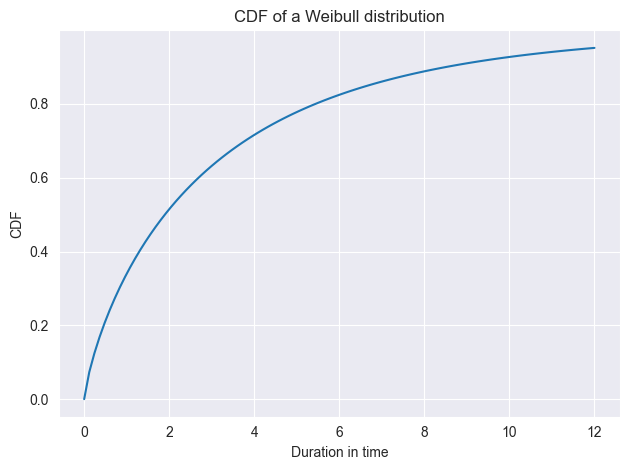

In [6]:
def weibull_dist(lamda_, k):
    return weibull_min(k, scale=lamda_)


lamda_ = 3
k = 0.8
actual_dist = weibull_dist(lamda_, k)

qs = np.linspace(0, 12, 101)
ps = actual_dist.cdf(qs)
cdf = Cdf(ps, qs)
cdf.plot()

decorate(
    xlabel='Duration in time', 
    ylabel='CDF',
    title='CDF of a Weibull distribution'
)

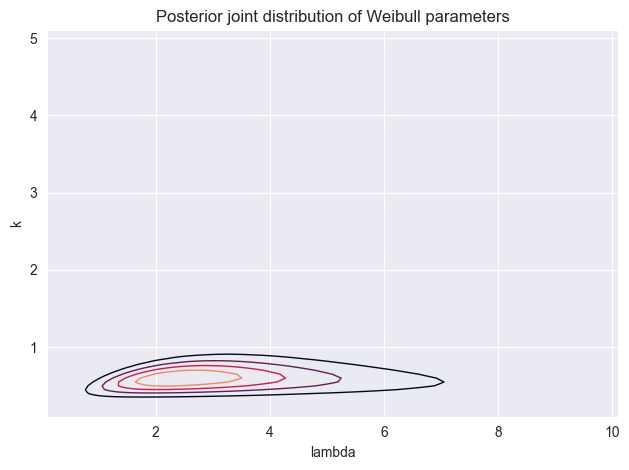

In [16]:
data = actual_dist.rvs(10)

lambdas = np.linspace(0.1, 10.1, num=101)
prior_lam = make_uniform(lambdas, name='lambda')

ks = np.linspace(0.1, 5.1, num=101)
prior_k = make_uniform(ks, name='k')

prior = make_joint(prior_lam, prior_k)

lamda_mesh, k_mesh, data_mesh = np.meshgrid(
    prior.columns, prior.index, data
)

densities = weibull_dist(lamda_mesh, k_mesh).pdf(data_mesh)
likelihood = densities.prod(axis=2)
posterior = prior * likelihood
normalize(posterior)


def update_weibull(prior, data):
    """Update the prior based on data."""
    lam_mesh, k_mesh, data_mesh = np.meshgrid(
        prior.columns, prior.index, data
    )
    
    densities = weibull_dist(lam_mesh, k_mesh).pdf(data_mesh)
    likelihood = densities.prod(axis=2)

    posterior = prior * likelihood
    normalize(posterior)

    return posterior


posterior = update_weibull(prior, data)
plot_contour(posterior)
decorate(title='Posterior joint distribution of Weibull parameters')

## 14.2 The Marginal Distributions

In [26]:
posterior_lamda = marginal(posterior, 0)
posterior_k = marginal(posterior, 1)

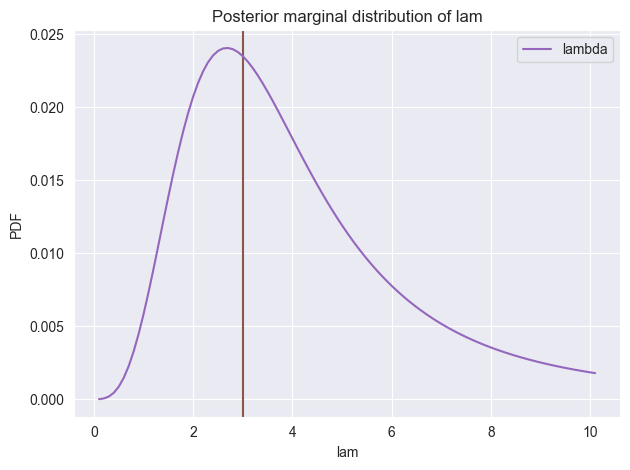

In [27]:
plt.axvline(3, color='C5')
posterior_lamda.plot(color='C4', label='lambda')
decorate(
    xlabel='lam',
    ylabel='PDF', 
    title='Posterior marginal distribution of lam'
)

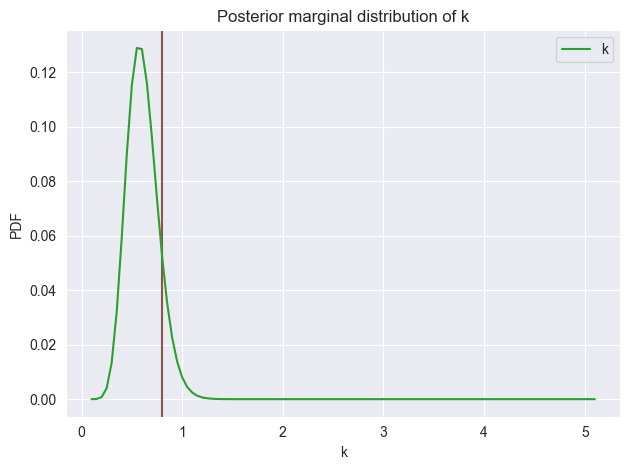

In [28]:
plt.axvline(0.8, color='C5')
posterior_k.plot(color='C12', label='k')
decorate(
    xlabel='k',
    ylabel='PDF', 
    title='Posterior marginal distribution of k'
)

In [29]:
print(lamda_, posterior_lamda.credible_interval(0.9))
print(k, posterior_k.credible_interval(0.9))

3 [1.4 8.1]
0.8 [0.35 0.9 ]


## 14.3 Incomplete Data

In [37]:
start = np.random.uniform(0, 8, size=10)
duration = actual_dist.rvs(10)

obs = pd.DataFrame({'start': start, 'end': start + duration}).sort_values('start', ignore_index=True)
obs

,start,end
0,0.242569,0.606505
1,0.711710,17.974097
2,1.043977,16.439380
3,1.713117,4.712447
4,3.227707,5.715287
5,3.312836,5.723149
6,4.751967,5.189706
7,6.299593,7.720626
8,6.772456,9.374973
9,6.811363,7.393803


In [38]:
censored = obs['end'] > 8
obs.loc[censored, 'end'] = 8
obs.loc[censored, 'status'] = 0
obs['T'] = obs['end'] - obs['start']
obs

,start,end,status,T
0,0.242569,0.606505,NaN,0.363935
1,0.711710,8.000000,0.0,7.288290
2,1.043977,8.000000,0.0,6.956023
3,1.713117,4.712447,NaN,2.999330
4,3.227707,5.715287,NaN,2.487580
5,3.312836,5.723149,NaN,2.410313
6,4.751967,5.189706,NaN,0.437739
7,6.299593,7.720626,NaN,1.421034
8,6.772456,8.000000,0.0,1.227544
9,6.811363,7.393803,NaN,0.582440


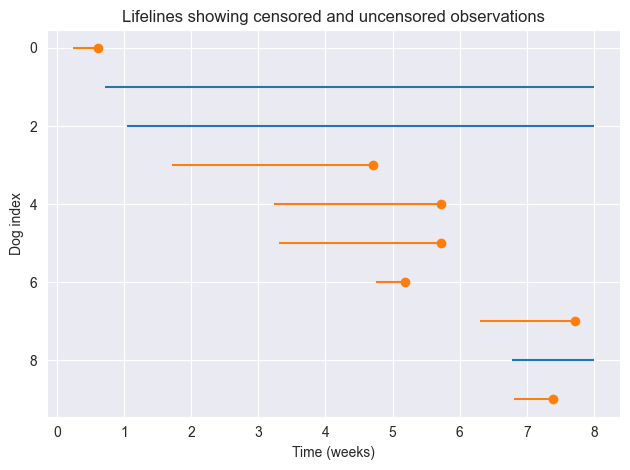

In [39]:
def plot_lifelines(obs):
    """Plot a line for each observation.
    
    obs: DataFrame
    """
    for y, row in obs.iterrows():
        start = row['start']
        end = row['end']
        status = row['status']
        
        if status == 0:
            # ongoing
            plt.hlines(y, start, end, color='C0')
        else:
            # complete
            plt.hlines(y, start, end, color='C1')
            plt.plot(end, y, marker='o', color='C1')
            
    decorate(
        xlabel='Time (weeks)',
        ylabel='Dog index',
        title='Lifelines showing censored and uncensored observations'
    )

    plt.gca().invert_yaxis()

plot_lifelines(obs)